# Game Theory

The Prisoner's Dilemma is a two players game commonly studied in Game Theory. The story goes:

There are two criminals and they have been arrested by the police. The criminals are put in separate cells and have no way of communicating with each other.

Unfortunately for the police officer there are not enough evidence to convince the criminals for a serious crime but only for minor theft. The officer then comes up with a way to trick the two prisoners.

Simultaneously, the police officer offer each prisoner a bargain. Each prisoner is given the opportunity either to betray the other by testifying that the other committed the crime, or to cooperate with the other by remaining silent. The offer is:

If A and B each betray the other, each of them serves two years in prison. If A betrays B but B remains silent, A will be set free and B will serve three years in prison (and vice versa) If A and B both remain silent, both of them will only serve one year in prison (on the lesser charge).

| Property | Prisoners Dilemma |
|----------|------------------|
|Cooperative / Non-cooperative	| Non-cooperative
Symmetric / Asymmetric|Symmetric
Zero-sum / Non-zero-sum|Non-zero-sum
Simultaneous / Sequential|Simultaneous
Nash Equilibirum | (Defect,Defect)

In game theory we represent such games using a matrix. Instead of months in prison we will be using a positive payoff (a gain) for each of the actions. See below:

                          Prisoner A
                     --------------------     
                     |Cooperate| Defect |    
           |---------|---------|--------|
           |Cooperate| (3, 3)  | (0, 5) |
           |---------|---------|--------|  Prisonner B
           | Defect  | (5, 0)  | (1, 1) |
           ------------------------------

Now let assume that the officer locks our two criminals back in prison and asks them the same question again the next day. Now let us assume that this is repeated for a given number of iterations. Then we have what is called the iterated prisoner's dilemma.

The Axelrod library is used to model the IPD. It manages to do so by creating a tournament where different strategies, sets of rules, (implemented within the library) compete in a round robin tournament.

# Creating matches

For now we are going to use two simple strategies to demonstrate how we create a match. A match is often useful when designing new strategies in order to study how they perform against specific opponents.

So for example let us create a 5 turns match between Cooperator and Random.

Cooperator is a strategy designed to cooperate and each turn, and Random is a strategy that cooperates at teach turn with a probability of 0.5.

In [2]:
!pip install axelrod

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 6.2 MB/s eta 0:00:00


In [3]:
import axelrod as axl

In [4]:
players = [axl.Cooperator(), axl.Random()]
match = axl.Match(players, turns=5, seed=0)
results = match.play()
results

[(C, D), (C, C), (C, C), (C, D), (C, D)]

The first elemeent of each tuple is the action made by Cooperator and the second one by Random. Indeed we can see that Cooperator played C for all five turns.

Random is a stochastic strategy and its actions depend on a probability. We can see that the strategy cooperated only on the third and fourth turn.

In [5]:
scores = match.scores()
scores

[(np.int64(0), np.int64(5)),
 (np.int64(3), np.int64(3)),
 (np.int64(3), np.int64(3)),
 (np.int64(0), np.int64(5)),
 (np.int64(0), np.int64(5))]

In [6]:
axl.game.Game()

Axelrod game: (R,P,S,T) = (np.int64(3), np.int64(1), np.int64(0), np.int64(5))

The letters represent the four possible payoffs in Prisoner's Dilemma.
R - reward, both cooperate
P - punishment, both defect
S - sucker's payoff, you cooperate, opponent defects
T - temptation, you defect, opponent cooperates

The final scores of a match, which are the sum of the scores per turn:

In [7]:
match.final_score()

(np.int64(6), np.int64(21))

The average score achieved per turn:

In [8]:
match.final_score_per_turn()

(np.float64(1.2), np.float64(4.2))

The winner:

In [9]:
match.winner()

Random: 0.5

The number of cooperations:

In [10]:
match.cooperation()

(5, 2)

The normalised number of cooperations:

In [11]:
match.normalised_cooperation()

(1.0, 0.4)

# Creating Tournaments

A tournament where each strategy plays against all opponents. The strategy with the highest score is the winner of the tournament.

Here we create a list of players:

In [12]:
players = [axl.Cooperator(), axl.Defector(), axl.Random(),
           axl.TitForTat(), axl.Grumpy(), axl.Alternator()]

1. Cooperator - always choose C
2. Defector - always choose D
3. Random - 50/50 probability to choose C or D
4. Tit for Tat - start by cooperating, then copy opponent's previous move
5. Grumpy - start by cooperating, then always defect after the first time the opponent defects
6. Alternator - alternate between C and D

We can now create a tournament, play it, save the results and view the rank of each player:

In [13]:
tournament = axl.Tournament(players=players, seed=1)
tournament.turns # default value of turns

200

In [14]:
tournament.repetitions # default value of repetitions

10

In [15]:
results = tournament.play()

Analysing: 100%|██████████| 25/25 [00:00<00:00, 105.62it/s]


The strategies ranked by their average score per turn:

In [17]:
winners = results.ranked_names
winners

['Defector',
 'Alternator',
 'Random: 0.5',
 'Tit For Tat',
 'Grumpy: Nice, 10, -10',
 'Cooperator']

The scores achieved by each strategy at each repetition:

In [19]:
scores = results.scores
scores

for i, player in enumerate(players):
    print(f'{player.name}:', scores[i])
    print("========================================================================")


Cooperator: [1794, 1782, 1779, 1830, 1782, 1806, 1776, 1854, 1812, 1779]
Defector: [2696, 2664, 2648, 2644, 2676, 2628, 2648, 2644, 2636, 2628]
Random: [2093, 2650, 2555, 2577, 2609, 2564, 2576, 2562, 2581, 2617]
Tit For Tat: [2355, 2376, 2327, 2339, 2366, 2336, 2321, 2333, 2329, 2343]
Grumpy: [2164, 1989, 1987, 2007, 2010, 1998, 2013, 1992, 1992, 2001]
Alternator: [2656, 2641, 2696, 2619, 2667, 2698, 2635, 2616, 2644, 2648]


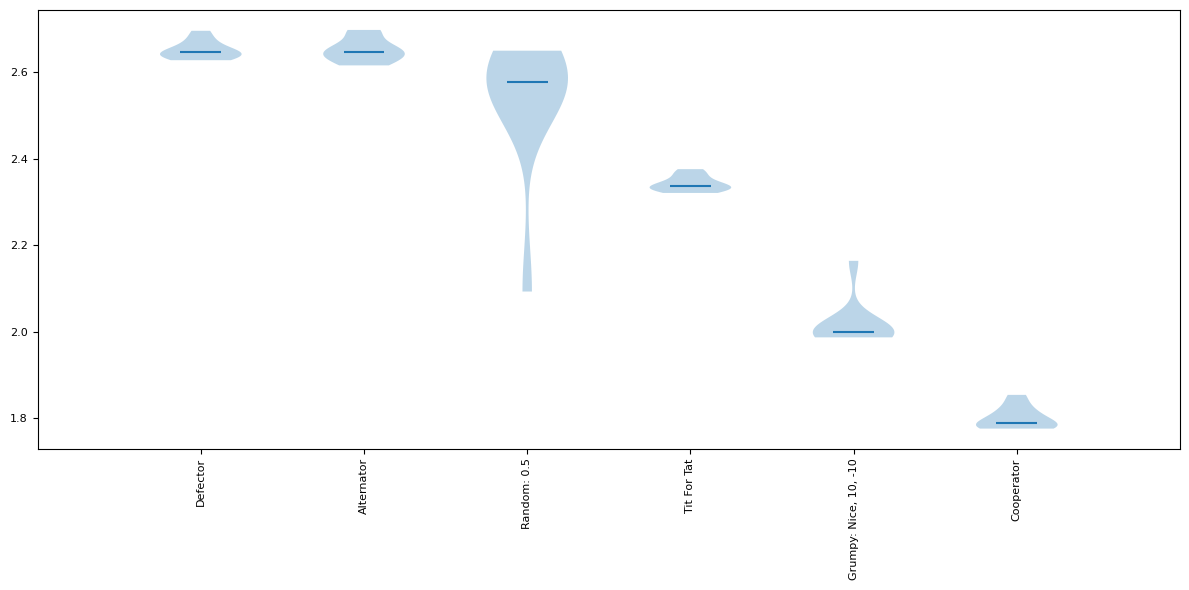

In [20]:
%matplotlib inline
plot = axl.Plot(results)
p = plot.boxplot()

The above plot shows several things.

1. The ranks of the strategies. From left to right the strategies are ordered based on their performance. Defector is first and thus is the winner of the tournament. Cooperator is last and thus came last in the tournament.

2. The distributions of the average score each strategy achieved. Random has the more variation in its distribution and thus the strategy has many different scores each time the tournament was repeated. As a reminder the tournament was repeated 10 times.

In [30]:
import axelrod as axl
import random

class Human(axl.Player):
    name = "Human"

    def strategy(self, opponent):
        print("\nOpponent history:", opponent.history)
        print("Your history:", self.history)

        while True:
            move = input("Enter C or D: ").upper()
            if move == "C":
                return axl.Action.C
            elif move == "D":
                return axl.Action.D


strategy_pool = [
    axl.Cooperator,
    axl.Defector,
    axl.TitForTat,
    axl.Grudger,
    axl.Random
]

opponent_class = random.choice(strategy_pool)
opponent = opponent_class()

me = Human()

players = [opponent, me]

match = axl.Match(players, turns=5)
match.play()

winner = match.winner()

if winner is None:
    winner_name = "Tie"
elif winner:
    winner_name = players[0].name
else:
    winner_name = players[1].name

print(
    "You competed against {}, final score: {}, winner: {}".format(
        opponent.name, match.final_score(), winner_name
    )
)


Opponent history: 
Your history: 
Enter C or D: C

Opponent history: C
Your history: C
Enter C or D: D

Opponent history: CC
Your history: CD
Enter C or D: D

Opponent history: CCD
Your history: CDD
Enter C or D: C

Opponent history: CCDD
Your history: CDDC
Enter C or D: D
You competed against Grudger, final score: (np.int64(10), np.int64(10)), winner: Human
